# Example 2. Physical effects of the attacks: linear regression as a model of normal behaviour

**Question:** while the network is under attack, do the electrical and mechanical signals of the microgrid equipment look different from normal operation?

**Idea:** during normal operation, physics ties the signals together with simple linear relations.
- **local2 (DC chopper):** P = V × I, and the DC bus voltage V is regulated at 75 V → **P ≈ 75 × I**
- **local1 (dynamometer):** P = T × ω, and the shaft turns at a constant 1500 rpm → **P ≈ (2π · 1500 / 60) × T ≈ 157 × T**

So a linear regression fit on normal data should have a **physical constant (bus voltage, shaft speed) as its slope**.
The **residual** (actual − predicted) is close to 0 in normal operation; a sample far from the line is an anomaly.

- Data: `data/processed/power_local1.csv`, `power_local2.csv` (built by `scripts/build_dataset.py`)
- Training: the first 70% of the **normal** recording only
- Evaluation: the remaining 30% of the normal recording (hold-out) and the whole malicious recording

### This is anomaly detection, not classification

The end result is "alarm or no alarm", so it looks like classification, but the setup is different:

| | Supervised classification (Example 1) | Normal-only anomaly detection (this notebook) |
|---|---|---|
| Training data | benign + attack, labels needed | **normal data only** |
| What it learns | a boundary between the classes | the normal physical relation (P ≈ 75 × I) |
| Output | a class | a residual = anomaly score → alarm beyond 4σ |
| Evaluation | accuracy, recall, macro-F1 | alarm rates only (see below) |

The attack labels are used **only for evaluation**. This framing fits the data: each device has one normal and one malicious recording,
and the dataset does not say *when* inside the malicious recording an attack was running. Most of the malicious recording looks normal,
so a classifier trained on these per-recording labels would learn "which recording", not "what an attack looks like".

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

import common
from common import BLUE, ORANGE, MUTED, GRID, INK, INK_2, SURFACE

common.apply_style()
TRAIN_FRAC = 0.7
THRESHOLD_SIGMA = 4

## 1. Look at the data

- `energy_wh` is a running total, and the malicious recording continues from where the normal one ended, so it leaks the label. We do not use it.
- The CSVs have no timestamps, so the x-axis is the sample order. `idx` numbers the samples continuously: normal recording first, then malicious.

In [2]:
p1 = pd.read_csv(common.DATA / "power_local1.csv")
p2 = pd.read_csv(common.DATA / "power_local2.csv")
for p in (p1, p2):
    p["idx"] = np.arange(len(p))  # one continuous axis: normal recording, then malicious
print("local1:", p1.groupby("condition").size().to_dict(), "| local2:", p2.groupby("condition").size().to_dict())
p2.groupby("condition")[["voltage_v", "current_a", "power_w"]].describe().T.round(2)

local1: {'malicious': 987, 'normal': 893} | local2: {'malicious': 903, 'normal': 833}


condition        malicious  normal
voltage_v count     903.00  833.00
          mean       74.08   74.90
          std         3.42    0.74
          min        59.79   59.83
          25%        74.88   74.88
          50%        74.91   74.90
          75%        74.94   74.93
          max        75.00   90.00
current_a count     903.00  833.00
          mean        0.57    0.57
          std         0.16    0.16
          min         0.28    0.35
          25%         0.42    0.41
          50%         0.55    0.57
          75%         0.72    0.72
          max         0.80    0.80
power_w   count     903.00  833.00
          mean       41.97   42.60
          std        11.87   11.90
          min        16.90   22.78
          25%        30.44   30.46
          50%        40.04   42.48
          75%        54.11   54.18
          max        59.82   59.77

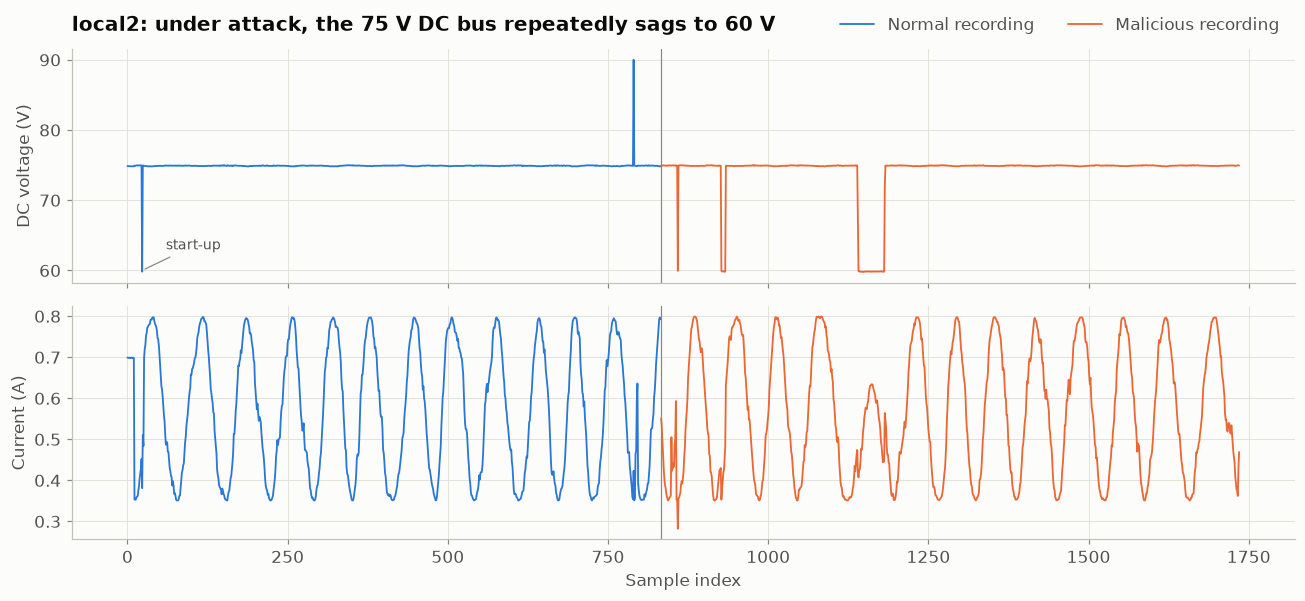

In [3]:
def shade_recordings(ax, p):
    start = p.loc[p["condition"] == "malicious", "idx"].min()
    ax.axvline(start, color=MUTED, linewidth=0.8)
    return start


fig, axes = plt.subplots(2, 1, figsize=(12, 5.6), sharex=True)
for ax, col, ylabel in [(axes[0], "voltage_v", "DC voltage (V)"), (axes[1], "current_a", "Current (A)")]:
    for cond, color in [("normal", BLUE), ("malicious", ORANGE)]:
        q = p2[p2["condition"] == cond]
        ax.plot(q["idx"], q[col], color=color, linewidth=1.2, label=f"{cond.capitalize()} recording")
    start = shade_recordings(ax, p2)
    ax.set_ylabel(ylabel)
axes[0].set_title("local2: under attack, the 75 V DC bus repeatedly sags to 60 V")
axes[0].annotate("start-up", xy=(23, 60), xytext=(60, 63), color=INK_2, fontsize=9,
                 arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
axes[1].set_xlabel("Sample index")
axes[0].legend(loc="lower right", ncols=2, bbox_to_anchor=(1, 1.0))
fig.tight_layout()
common.save(fig, "power_01_local2_timeseries")
plt.show()

The current follows the load cycle and the voltage holds at 75 V.
In the malicious recording the voltage **sags** (drops briefly) to 60 V several times, and the current pattern is disturbed while it does.
The single dip at the very start of the normal recording is the start-up transient right after the equipment powers on.

## 2. local2: linear regression `power ~ current`

In [4]:
def split(p):
    normal = p[p["condition"] == "normal"]
    cut = int(len(normal) * TRAIN_FRAC)
    return {
        "train (normal 70%)": normal.iloc[:cut],
        "hold-out normal": normal.iloc[cut:],
        "malicious": p[p["condition"] == "malicious"],
    }


def fit_and_score(p, x, y):
    parts = split(p)
    model = LinearRegression().fit(parts["train (normal 70%)"][[x]], parts["train (normal 70%)"][y])
    p = p.assign(pred=model.predict(p[[x]]))
    p["resid"] = p[y] - p["pred"]
    train_resid = p.loc[parts["train (normal 70%)"].index, "resid"]
    threshold = THRESHOLD_SIGMA * train_resid.std()
    p["alarm"] = p["resid"].abs() > threshold
    rows = {}
    for name, part in parts.items():
        q = p.loc[part.index]
        rows[name] = {
            "n": len(q),
            "R2": r2_score(q[y], q["pred"]),
            "MAE": mean_absolute_error(q[y], q["pred"]),
            "alarms": int(q["alarm"].sum()),
            "alarm %": q["alarm"].mean() * 100,
        }
    return model, p, threshold, parts, pd.DataFrame(rows).T.astype({"n": int, "alarms": int})


lr2, p2, thr2, parts2, scores2 = fit_and_score(p2, "current_a", "power_w")
print(f"power_w = {lr2.coef_[0]:.2f} * current_a + {lr2.intercept_:.2f}")
print(f"alarm threshold = ±{thr2:.2f} W ({THRESHOLD_SIGMA}σ of training residuals)")
scores2.round(4)

power_w = 74.85 * current_a + 0.01
alarm threshold = ±0.96 W (4σ of training residuals)


,n,R2,MAE,alarms,alarm %
train (normal 70%),583,0.9996,0.0354,1,0.1715
hold-out normal,250,0.9988,0.0514,1,0.4000
malicious,903,0.9755,0.4571,51,5.6478


The learned slope is **74.85**. Its unit is W/A = V, so the model has recovered the **75 V bus voltage** on its own.

### Caution: this result is close to trivial

The `power_w` column appears to be computed by the meter as V × I rather than measured independently. Let's check.

In [5]:
v_times_i = p2["voltage_v"] * p2["current_a"]
print(f"max |power_w - V*I| = {(p2['power_w'] - v_times_i).abs().max():.3f} W  "
      f"(power_w ranges {p2['power_w'].min():.1f} to {p2['power_w'].max():.1f} W)")
voltage_effect = (p2["voltage_v"] - lr2.coef_[0]) * p2["current_a"]
print(f"corr(residual, (V - {lr2.coef_[0]:.2f}) * I) = {np.corrcoef(p2['resid'], voltage_effect)[0, 1]:.4f}")

max |power_w - V*I| = 0.044 W  (power_w ranges 16.9 to 59.8 W)
corr(residual, (V - 74.85) * I) = 0.9999


Power is V × I up to rounding, so the fit can only find 75 V again, and the residual is essentially **(V − 75) × I**:
a check of how far the voltage strays from 75 V. Keep this in mind when reading the alarms below.
A physics-based residual becomes useful when it cross-checks **independent** sensors, for example to catch a falsified sensor value (false data injection).

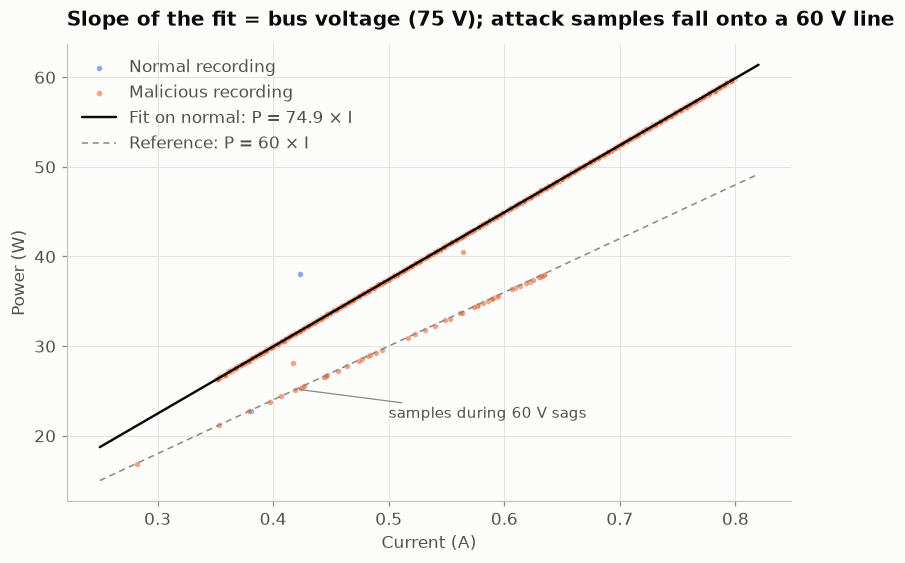

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.4))
normal, malicious = p2[p2["condition"] == "normal"], p2[p2["condition"] == "malicious"]
ax.scatter(normal["current_a"], normal["power_w"], s=14, color=BLUE, alpha=0.6,
           edgecolor=SURFACE, linewidth=0.4, label="Normal recording")
ax.scatter(malicious["current_a"], malicious["power_w"], s=14, color=ORANGE, alpha=0.6,
           edgecolor=SURFACE, linewidth=0.4, label="Malicious recording")
xs = np.linspace(0.25, 0.82, 50)
ax.plot(xs, lr2.predict(pd.DataFrame({"current_a": xs})), color=INK, linewidth=1.6,
        label=f"Fit on normal: P = {lr2.coef_[0]:.1f} × I")
ax.plot(xs, 60 * xs, color=MUTED, linewidth=1, linestyle=(0, (4, 3)), label="Reference: P = 60 × I")
ax.annotate("samples during 60 V sags", xy=(0.42, 60 * 0.42), xytext=(0.5, 22),
            color=INK_2, fontsize=10, arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.8))
ax.set_xlabel("Current (A)")
ax.set_ylabel("Power (W)")
ax.set_title("Slope of the fit = bus voltage (75 V); attack samples fall onto a 60 V line")
ax.legend(loc="upper left")
common.save(fig, "power_02_local2_fit")
plt.show()

### Find anomalies with the residual

A sample raises an **alarm** when its residual is larger than 4σ, four times the standard deviation of the training residuals.
For normally distributed residuals that would happen less than 0.01% of the time.

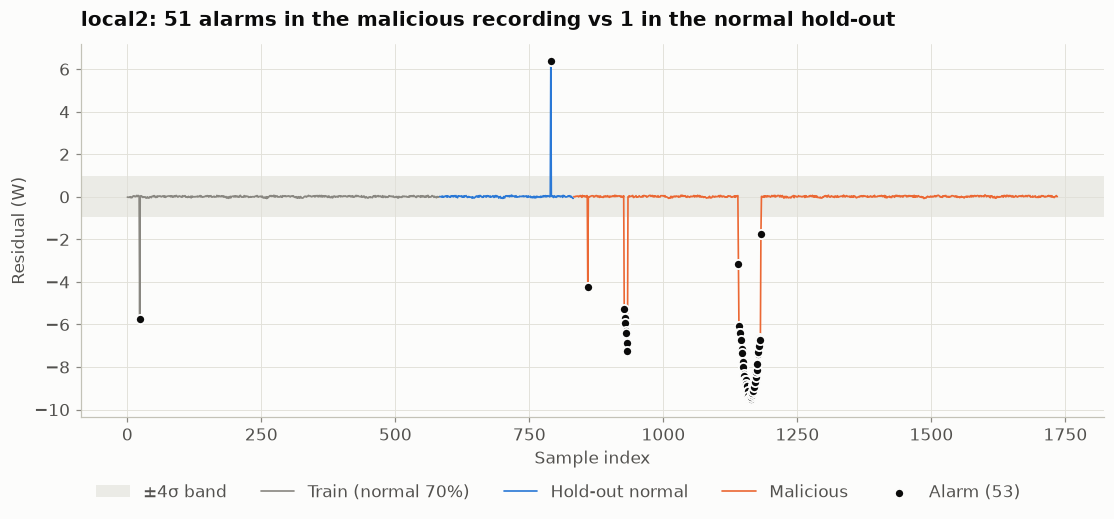

In [7]:
def plot_residuals(ax, p, parts, threshold, unit):
    ax.axhspan(-threshold, threshold, color=GRID, alpha=0.6, linewidth=0, label=f"±{THRESHOLD_SIGMA}σ band")
    for name, color in [("train (normal 70%)", MUTED), ("hold-out normal", BLUE), ("malicious", ORANGE)]:
        q = p.loc[parts[name].index]
        ax.plot(q["idx"], q["resid"], color=color, linewidth=1.1, label=name.capitalize())
    alarms = p[p["alarm"]]
    ax.scatter(alarms["idx"], alarms["resid"], s=36, color=INK, edgecolor=SURFACE, linewidth=1.2,
               zorder=3, label=f"Alarm ({len(alarms)})")
    ax.set_xlabel("Sample index")
    ax.set_ylabel(f"Residual ({unit})")


fig, ax = plt.subplots(figsize=(12, 4.4))
plot_residuals(ax, p2, parts2, thr2, "W")
n_ho, n_mal = scores2.loc["hold-out normal", "alarms"], scores2.loc["malicious", "alarms"]
ax.set_title(f"local2: {n_mal} alarms in the malicious recording vs {n_ho} in the normal hold-out")
ax.legend(loc="upper left", ncols=5, bbox_to_anchor=(0, -0.14))
common.save(fig, "power_03_local2_residuals")
plt.show()

In [8]:
alarms = p2[p2["alarm"]]
print("Voltage at alarm samples:")
pd.crosstab(alarms["condition"], alarms["voltage_v"].round().rename("voltage (V)"))

Voltage at alarm samples:


voltage (V),60.0,67.0,72.0,90.0
condition,,,,
malicious,49,1,1,0
normal,1,0,0,1


Almost every alarm in the malicious recording falls on a moment when **the voltage sagged to 60 V**.
The two alarms in the normal recording are the start-up transient (in the training part) and a brief spike to 90 V (in the hold-out).

**What can we claim from this?** We do not know which samples were under attack, so per-sample precision and recall cannot be computed.
We can only compare **alarm rates** between the normal hold-out and the malicious recording.
And since the residual is effectively a voltage check, it reaches the same conclusion as the voltage plot in section 1.

## 3. local1: linear regression `power ~ torque` (motor shaft)

In [9]:
lr1, p1, thr1, parts1, scores1 = fit_and_score(p1, "torque_nm", "power_w")
implied_rpm = lr1.coef_[0] * 60 / (2 * np.pi)
print(f"power_w = {lr1.coef_[0]:.2f} * torque_nm + {lr1.intercept_:.2f}")
print(f"slope -> implied shaft speed = {lr1.coef_[0]:.2f} * 60 / 2π = {implied_rpm:.0f} rpm (nominal 1500 rpm)")
scores1.round(4)

power_w = 156.86 * torque_nm + -0.02
slope -> implied shaft speed = 156.86 * 60 / 2π = 1498 rpm (nominal 1500 rpm)


,n,R2,MAE,alarms,alarm %
train (normal 70%),625,0.9998,0.0653,1,0.1600
hold-out normal,268,0.9999,0.0545,1,0.3731
malicious,987,1.0000,0.0447,0,0.0000


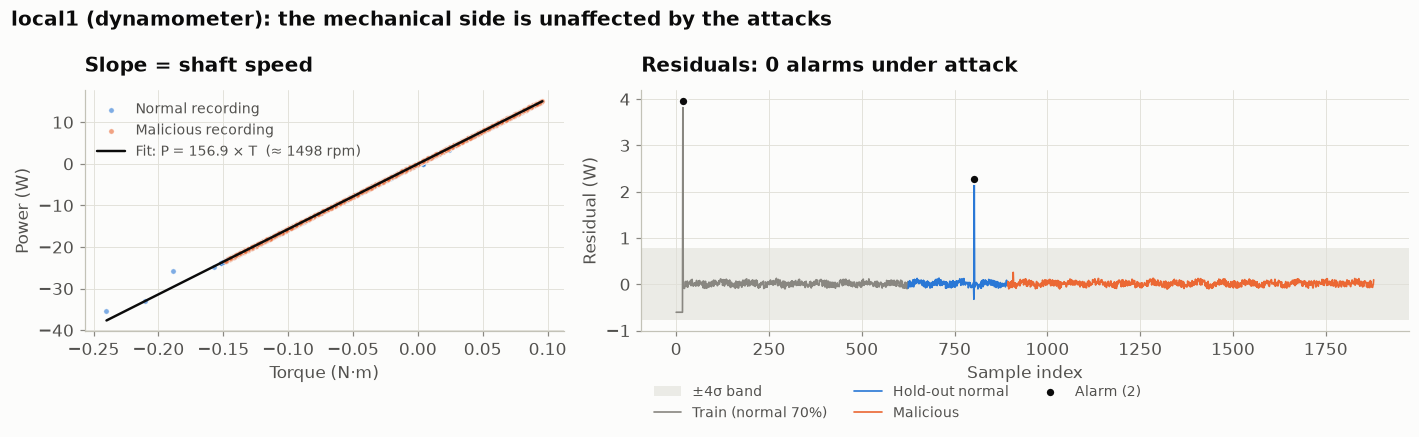

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.6]})
ax = axes[0]
for cond, color in [("normal", BLUE), ("malicious", ORANGE)]:
    q = p1[p1["condition"] == cond]
    ax.scatter(q["torque_nm"], q["power_w"], s=12, color=color, alpha=0.6, edgecolor=SURFACE,
               linewidth=0.4, label=f"{cond.capitalize()} recording")
xs = np.linspace(p1["torque_nm"].min(), p1["torque_nm"].max(), 50)
ax.plot(xs, lr1.predict(pd.DataFrame({"torque_nm": xs})), color=INK, linewidth=1.6,
        label=f"Fit: P = {lr1.coef_[0]:.1f} × T  (≈ {implied_rpm:.0f} rpm)")
ax.set_xlabel("Torque (N·m)")
ax.set_ylabel("Power (W)")
ax.set_title("Slope = shaft speed")
ax.legend(loc="upper left", fontsize=9)

plot_residuals(axes[1], p1, parts1, thr1, "W")
axes[1].set_title(f"Residuals: {scores1.loc['malicious', 'alarms']} alarms under attack")
axes[1].legend(loc="lower left", ncols=3, bbox_to_anchor=(0, -0.42), fontsize=9)
fig.suptitle("local1 (dynamometer): the mechanical side is unaffected by the attacks", x=0.01, ha="left",
             fontweight="bold", fontsize=13)
fig.tight_layout()
common.save(fig, "power_04_local1")
plt.show()

The fit is essentially perfect (R² ≈ 1 on both recordings) and there are **zero alarms** under attack.
That does not mean the model failed; there was nothing to catch. Let's look for samples where the shaft left 1500 rpm.

In [11]:
off_speed = p1[(p1["condition"] == "malicious") & ((p1["speed_rpm"] - 1500).abs() > 5)]
print(f"malicious samples more than 5 rpm away from 1500 rpm: {len(off_speed)}")
print(f"alarm threshold: ±{thr1:.2f} W")
off_speed[["t", "speed_rpm", "torque_nm", "power_w", "pred", "resid", "alarm"]].round(3)

malicious samples more than 5 rpm away from 1500 rpm: 1
alarm threshold: ±0.78 W


,t,speed_rpm,torque_nm,power_w,pred,resid,alarm
908,15,1376,-0.015,-2.118,-2.376,0.258,False


Only one sample in the malicious recording left the 1500 ± 5 rpm range. But torque was almost zero at that moment,
so P = T × ω is close to 0 whatever the speed, and the residual stays far inside the band.
This residual has a **blind spot**: it cannot see speed changes when the torque is small.

Apart from that one sample, the motor shaft kept turning at 1500 rpm during the attacks: in this release, the physical effect shows up only on the DC bus (local2).

## 4. Optional: a time-series regression (AR model)

The `power ~ current` model is close to trivial. A natural next try is to predict the **current** from its own recent past,
an autoregressive model AR(k): `current[t] ≈ a1·current[t-1] + … + ak·current[t-k] + b`, trained on normal data only.
If the attacks disturbed the load cycle, the malicious recording should raise more alarms.

In [12]:
def lagged(p, col, k):
    frames = []
    for cond, g in p.groupby("condition", sort=False):  # build lags inside each recording
        lags = pd.concat({f"lag{i}": g[col].shift(i) for i in range(1, k + 1)}, axis=1)
        frames.append(lags.assign(y=g[col], condition=cond).dropna())
    return pd.concat(frames)


rows = {}
for k in (3, 5):
    d = lagged(p2, "current_a", k)
    normal = d[d["condition"] == "normal"]
    cut = int(len(normal) * TRAIN_FRAC)
    parts = {"train": normal.iloc[:cut], "hold-out normal": normal.iloc[cut:], "malicious": d[d["condition"] == "malicious"]}
    lags = [f"lag{i}" for i in range(1, k + 1)]
    ar = LinearRegression().fit(parts["train"][lags], parts["train"]["y"])
    threshold = THRESHOLD_SIGMA * (parts["train"]["y"] - ar.predict(parts["train"][lags])).std()
    for name, q in parts.items():
        pred = ar.predict(q[lags])
        rows[(f"AR({k})", name)] = {"R2": r2_score(q["y"], pred),
                                    "alarm %": ((q["y"] - pred).abs() > threshold).mean() * 100}
pd.DataFrame(rows).T.round(3)

R2  alarm %
AR(3) train            0.981    0.688
      hold-out normal  0.972    0.803
      malicious        0.985    0.556
AR(5) train            0.982    0.691
      hold-out normal  0.973    1.205
      malicious        0.986    0.780

The AR models predict the current well (R² ≈ 0.97–0.99), but the malicious recording raises **no more alarms** than the normal hold-out (0.6–0.8% vs 0.8–1.2%).
Beyond the voltage sags, the current carries no extra attack signal that this simple model can see. A negative result like this is still a result: it tells us where the information in the data is (and is not).

## 5. Summary

In [13]:
summary = pd.DataFrame({
    "local2: power ~ current": {
        "slope": f"{lr2.coef_[0]:.2f} W/A",
        "physical meaning": "DC bus voltage ≈ 75 V",
        "R² hold-out normal": round(scores2.loc["hold-out normal", "R2"], 4),
        "R² malicious": round(scores2.loc["malicious", "R2"], 4),
        "alarm % hold-out normal": round(scores2.loc["hold-out normal", "alarm %"], 1),
        "alarm % malicious": round(scores2.loc["malicious", "alarm %"], 1),
    },
    "local1: power ~ torque": {
        "slope": f"{lr1.coef_[0]:.2f} W/(N·m)",
        "physical meaning": f"shaft speed ≈ {implied_rpm:.0f} rpm",
        "R² hold-out normal": round(scores1.loc["hold-out normal", "R2"], 4),
        "R² malicious": round(scores1.loc["malicious", "R2"], 4),
        "alarm % hold-out normal": round(scores1.loc["hold-out normal", "alarm %"], 1),
        "alarm % malicious": round(scores1.loc["malicious", "alarm %"], 1),
    },
})
summary

,local2: power ~ current,local1: power ~ torque
slope,74.85 W/A,156.86 W/(N·m)
physical meaning,DC bus voltage ≈ 75 V,shaft speed ≈ 1498 rpm
R² hold-out normal,0.9988,0.9999
R² malicious,0.9755,1.0
alarm % hold-out normal,0.4,0.4
alarm % malicious,5.6,0.0


| Observation | What it means |
|---|---|
| Regression trained on normal data only; residual = anomaly score | Anomaly detection without attack labels, not classification |
| Slopes are physical constants (75 V, ~1500 rpm) | Linear regression is easy to interpret: the coefficients are the system's normal operating point. |
| local2: alarms in 5.6% of the malicious recording vs 0.4% of the normal hold-out, almost all in 60 V sags | In this release, the attacks' physical trace is essentially these voltage sags. |
| local1: R² ≈ 1, 0 alarms under attack | No visible effect on the motor shaft; the one off-speed sample hides behind near-zero torque. |
| AR model of the current: no higher alarm rate under attack | No extra attack signal in the current beyond the sags. |

### Limitations

- **Close to trivial:** power is computed as V × I, so the local2 residual is effectively a voltage check, (V − 75) × I.
- **Per-recording labels:** one normal and one malicious recording per device, with no attack timing, so only alarm rates can be compared; no precision or recall.
- **Small data:** a few hundred samples per recording, with no timestamps to align them with the network captures.

## Things to try

1. Change `THRESHOLD_SIGMA` from 2 to 6 and plot the alarm rate of both recordings. Where do the two curves separate?
2. Regress `power_w` on `speed_rpm` and `torque_nm` together, or use their product. Does the local1 blind spot go away?
3. Use the local2 waveform channels (`ch1_rms_v`, `ch2_rms_v`, …) as inputs. Is any relation between independent sensors broken during the sags?
4. Replace the 4σ rule with a robust threshold (median ± k·MAD). How sensitive are the conclusions to the start-up transient in the training data?